<a href="https://colab.research.google.com/github/Asaf21S/constrained-flow-matching/blob/main/constrained_fm/notebooks/constrained_fm_2d_gmm_functa.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Imports

In [2]:
!pip install -q flow_matching POT

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.2/44.2 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.7/48.7 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 32.9/32.9 MB 59.8 MB/s eta 0:00:00


In [3]:
import sys
import os
import copy
import math
import random
from pathlib import Path

import matplotlib.patches as patches
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from matplotlib import cm
from torch.distributions import Categorical, Independent, MixtureSameFamily, MultivariateNormal, Normal
from torch.utils.data import DataLoader, TensorDataset
from tqdm.auto import tqdm

from flow_matching.path import AffineProbPath
from flow_matching.path.scheduler import CondOTScheduler
from flow_matching.solver import ODESolver, Solver
from flow_matching.utils import ModelWrapper
from torch.func import vmap

In [4]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

In [5]:
!git clone https://github.com/Asaf21S/constrained-flow-matching.git

repo_path = '/content/constrained-flow-matching'
if repo_path not in sys.path:
    sys.path.append(repo_path)

Cloning into 'constrained-flow-matching'...
remote: Enumerating objects: 1024, done.
remote: Counting objects: 100% (86/86), done.
remote: Compressing objects: 100% (61/61), done.
remote: Total 1024 (delta 42), reused 62 (delta 24), pack-reused 938 (from 1)
Receiving objects: 100% (1024/1024), 185.32 MiB | 20.19 MiB/s, done.
Resolving deltas: 100% (465/465), done.


In [6]:
# update the cloned repo after pushing changes in pycharm
%cd /content/constrained-flow-matching
!git pull origin main
%cd /content

/content/constrained-flow-matching
From https://github.com/Asaf21S/constrained-flow-matching
 * branch            main       -> FETCH_HEAD
Already up to date.
/content


In [ ]:
import importlib

import constrained_fm.src.datasets.gmm_target
import constrained_fm.src.datasets.validation
import constrained_fm.src.datasets.constraints

import constrained_fm.src.geometry.polynomials
import constrained_fm.src.geometry.bounding_boxes

import constrained_fm.src.models.base_fm
import constrained_fm.src.models.unconstrained
import constrained_fm.src.models.constrained_bbox
import constrained_fm.src.models.constrained_poly
import constrained_fm.src.models.area_predictor
import constrained_fm.src.solvers.ode_wrapper

import constrained_fm.src.inference.evaluator
import constrained_fm.src.inference.compound_sampler
import constrained_fm.src.inference.importance_sampling

import constrained_fm.src.metrics.success_rates
import constrained_fm.src.metrics.logger

import constrained_fm.src.visualization.density
import constrained_fm.src.visualization.scatter
import constrained_fm.src.visualization.constraints

import constrained_fm.src.models.functa_siren
import constrained_fm.src.inference.latent_extractor
import constrained_fm.src.models.constrained_functa
import constrained_fm.src.datasets.functa_conditioning

# 2. Reload them all (Order matters: base classes/math first, high-level last)
for _ in range(3):
    importlib.reload(constrained_fm.src.geometry.polynomials)
    importlib.reload(constrained_fm.src.geometry.bounding_boxes)

    importlib.reload(constrained_fm.src.datasets.gmm_target)
    importlib.reload(constrained_fm.src.datasets.validation)
    importlib.reload(constrained_fm.src.datasets.constraints)

    importlib.reload(constrained_fm.src.models.base_fm) # Reload base first!
    importlib.reload(constrained_fm.src.models.unconstrained)
    importlib.reload(constrained_fm.src.models.constrained_bbox)
    importlib.reload(constrained_fm.src.models.constrained_poly)
    importlib.reload(constrained_fm.src.models.area_predictor)
    importlib.reload(constrained_fm.src.solvers.ode_wrapper)

    importlib.reload(constrained_fm.src.metrics.success_rates)
    importlib.reload(constrained_fm.src.metrics.logger)

    importlib.reload(constrained_fm.src.visualization.density)
    importlib.reload(constrained_fm.src.visualization.scatter)
    importlib.reload(constrained_fm.src.visualization.constraints)

    importlib.reload(constrained_fm.src.models.functa_siren)
    importlib.reload(constrained_fm.src.inference.latent_extractor)
    importlib.reload(constrained_fm.src.models.constrained_functa)
    importlib.reload(constrained_fm.src.datasets.functa_conditioning)

    importlib.reload(constrained_fm.src.inference.evaluator)
    importlib.reload(constrained_fm.src.inference.compound_sampler)
    importlib.reload(constrained_fm.src.inference.importance_sampling)

# Datasets & Constraints
from constrained_fm.src.datasets.gmm_target import get_points, compute_gmm_log_likelihood
from constrained_fm.src.datasets.validation import get_validation_set
from constrained_fm.src.datasets.constraints import sample_valid_polynomials, generate_mass_dataset_anchored

# Geometry & Math
from constrained_fm.src.geometry.polynomials import compute_poly_features, evaluate_poly, compute_poly_features_batched, evaluate_poly_batched
from constrained_fm.src.geometry.bounding_boxes import generate_disjoint_bboxes

# Models
from constrained_fm.src.models.unconstrained import UnconstrainedFM
from constrained_fm.src.models.constrained_bbox import BboxConstrainedFM
from constrained_fm.src.models.constrained_poly import PolynomialConstrainedFM
from constrained_fm.src.models.area_predictor import AreaPredictor
from constrained_fm.src.solvers.ode_wrapper import WrappedModel

# Inference & Evaluation Run
from constrained_fm.src.inference.evaluator import run_evaluation_inference, evaluate_single_configuration, evaluate_validation_set_metrics
from constrained_fm.src.inference.compound_sampler import generate_from_boxes, generate_compound_constrained_points
from constrained_fm.src.inference.importance_sampling import estimate_mass_importance_sampling

# Metrics & Logging
from constrained_fm.src.metrics.success_rates import (compute_success_rate_bbox,
                                                      compute_success_rate_polynomial,
                                                      evaluate_compound_metrics)
from constrained_fm.src.metrics.logger import (log_evaluation_metrics,
                                               load_logged_metrics,
                                               print_readme_metrics_table)

# Visualization
from constrained_fm.src.visualization.density import (visualize_true_gmm_likelihood,
                                                      visualize_likelihood,
                                                      visualize_tiled_reconstruction)
from constrained_fm.src.visualization.scatter import (visualize_single_step,
                                                      plot_loss_curve,
                                                      generate_and_visualize_samples)
from constrained_fm.src.visualization.constraints import (visualize_sampled_polynomials,
                                                          visualize_predicted_bbox_mass,
                                                          visualize_disjoint_bboxes,
                                                          visualize_compound_generation)

from constrained_fm.src.models.functa_siren import ModulatedSIREN, build_modulated_siren
from constrained_fm.src.inference.latent_extractor import extract_latent, extract_latents_batched
from constrained_fm.src.models.constrained_functa import ConstrainedFlowMatcher
from constrained_fm.src.datasets.functa_conditioning import (generate_functa_conditioned_batch,
                                                            build_functa_pool,
                                                            sample_from_functa_pool)


# Displaying Priors

In [ ]:
n_train_samples = 100000
x0 = torch.randn(n_train_samples, 2)
gmm_true_pool, x1_labels = get_points(100000, device=device)
x1, x1_labels = gmm_true_pool.cpu(), x1_labels.cpu()

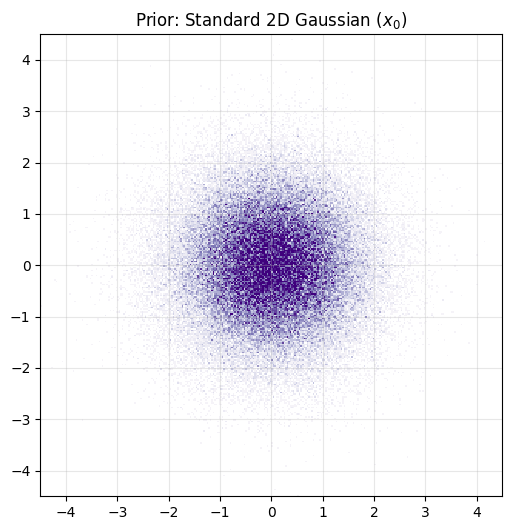

In [ ]:
visualize_single_step(x0, title="Prior: Standard 2D Gaussian ($x_0$)", cmap='Purples')
plt.show()

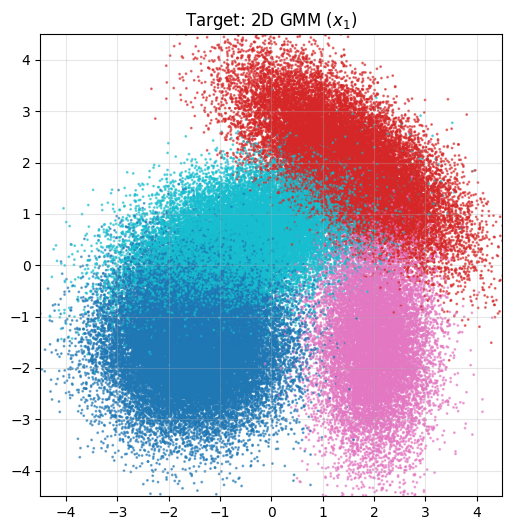

In [ ]:
visualize_single_step(x1, title="Target: 2D GMM ($x_1$)", cmap='Blues', labels=x1_labels)
plt.show()

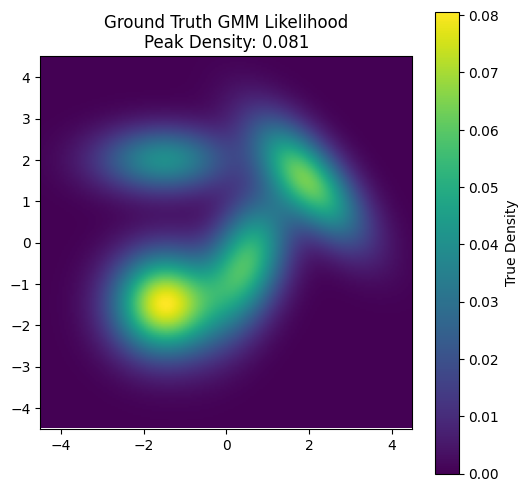

In [ ]:
visualize_true_gmm_likelihood(device=device)

# Functa

## Display polynomials dataset

In [ ]:
from constrained_fm.src.consts import POLYNOMIAL_DEGREE, PLANE_SCALE

num_plots = 4
poly_degree = POLYNOMIAL_DEGREE
plane_scale = PLANE_SCALE
resolution = 200


In [9]:
proxy_x, _ = get_points(batch_size=10000, device=device)
proxy_x = proxy_x.to(device)

proxy_x_batched = proxy_x.unsqueeze(0)
global_proxy_x_pow, global_proxy_y_pow = compute_poly_features_batched(proxy_x_batched, degree=poly_degree, scale=plane_scale)

In [10]:
C = sample_valid_polynomials(
    batch_size=num_plots,
    degree=poly_degree,
    scale=plane_scale,
    proxy_x_pow=global_proxy_x_pow.squeeze(0),
    proxy_y_pow=global_proxy_y_pow.squeeze(0),
    device=device
)

x_lin = torch.linspace(-plane_scale, plane_scale, resolution)
y_lin = torch.linspace(-plane_scale, plane_scale, resolution)
grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')

grid_pts = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2).unsqueeze(0).to(device)

grid_pts_batched = grid_pts.repeat(num_plots, 1, 1)

x_pow, y_pow = compute_poly_features_batched(grid_pts_batched, degree=poly_degree, scale=plane_scale)

P_vals = evaluate_poly_batched(x_pow, y_pow, C)

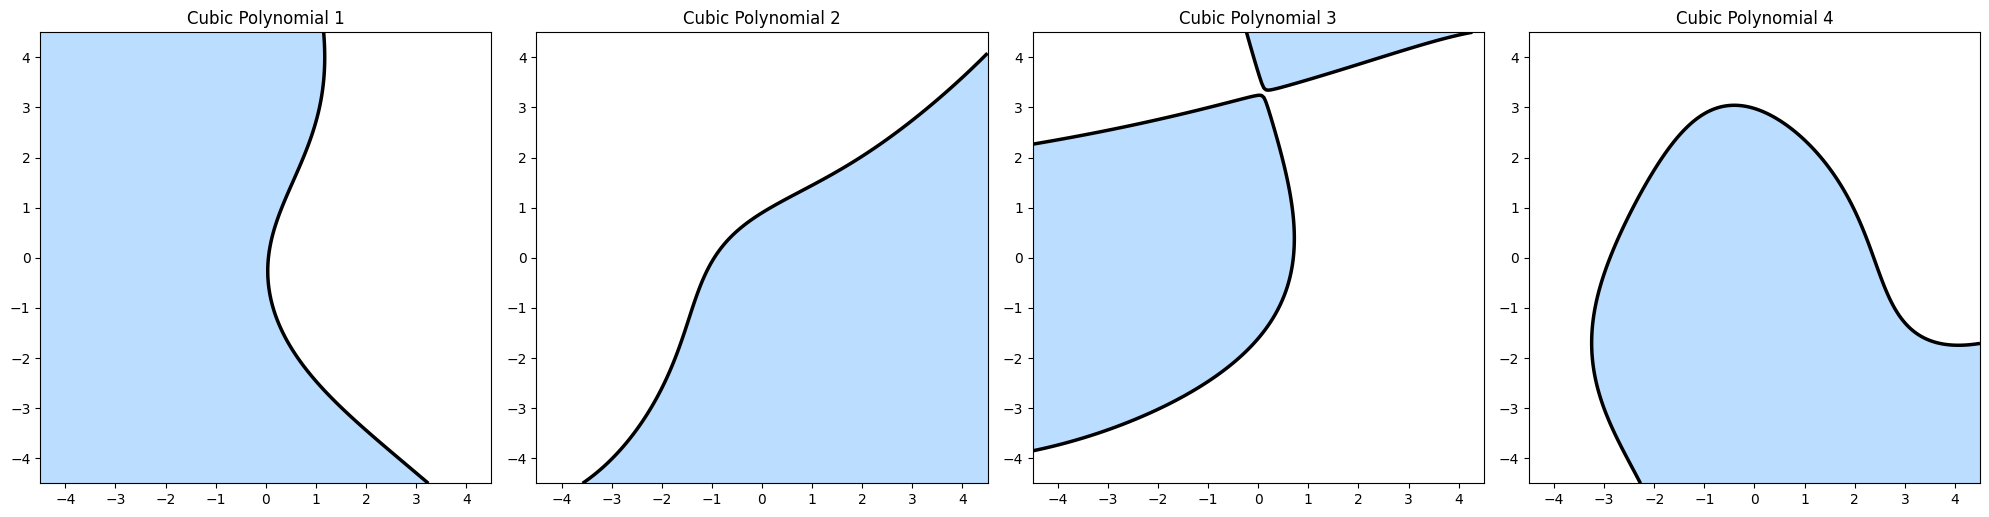

In [11]:
fig, axes = plt.subplots(1, num_plots, figsize=(5 * num_plots, 5))
if num_plots == 1: axes = [axes]

P_numpy = P_vals.view(num_plots, resolution, resolution).cpu().numpy()

for i in range(num_plots):
    ax = axes[i]

    # Shade the valid region P(x, y) <= 0
    ax.contourf(
        grid_x.numpy(), grid_y.numpy(), P_numpy[i],
        levels=[-float('inf'), 0], colors=['dodgerblue'], alpha=0.3
    )

    # Draw the exact boundary P(x, y) = 0
    ax.contour(
        grid_x.numpy(), grid_y.numpy(), P_numpy[i],
        levels=[0], colors='black', linewidths=2.5
    )

    ax.set_xlim(-plane_scale, plane_scale)
    ax.set_ylim(-plane_scale, plane_scale)
    ax.set_aspect('equal')
    ax.set_title(f"Cubic Polynomial {i+1}")

plt.tight_layout()
plt.show()

## Model

In [12]:
latent_dim=512
hidden_dim=512
n_layers=4
w0=30.0

siren = build_modulated_siren(latent_dim=latent_dim, hidden_dim=hidden_dim, n_layers=n_layers, w0=w0).to(device)

# Use cached model

In [ ]:
siren_path = Path(repo_path) / "constrained_fm" / "functa_dataset" / "siren_best.pt"
siren.load_state_dict(torch.load(siren_path, map_location=device, weights_only=True))
siren.eval()


In [ ]:
train_loss_path = Path(repo_path) / "constrained_fm" / "functa_dataset" / "loss_history.npy"
val_loss_path = Path(repo_path) / "constrained_fm" / "functa_dataset" / "val_loss_history.npy"

loss_history = np.load(train_loss_path)
val_loss_history = np.load(val_loss_path)
val_epochs = val_loss_history[:, 0]
val_losses = val_loss_history[:, 1]


In [ ]:
plt.figure(figsize=(10, 5))

plt.plot(range(1, len(loss_history) + 1), loss_history, label="Training Loss (MSE + L2)", color="royalblue", alpha=0.8)
plt.plot(val_epochs, val_losses, label="Validation Loss (MSE)", color="crimson", marker="o", markersize=4, linewidth=2)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("CAVIA Training & Validation Curves")
plt.grid(True, linestyle="--", alpha=0.6)
plt.legend()
plt.show()


# Run inference

In [ ]:
def run_functa_inference_pipeline(siren, num_shapes=4, scale=PLANE_SCALE, degree=POLYNOMIAL_DEGREE,
                                   points_per_shape=10000, steps=15):
    """Samples novel polynomials and extracts their Functa latents via CAVIA adaptation."""
    device = next(siren.parameters()).device

    C = sample_valid_polynomials(
        batch_size=num_shapes, degree=degree, scale=scale,
        proxy_x_pow=global_proxy_x_pow.squeeze(0),
        proxy_y_pow=global_proxy_y_pow.squeeze(0), device=device
    )

    X_raw = (torch.rand(num_shapes, points_per_shape, 2, device=device) * (scale * 2)) - scale
    x_pow, y_pow = compute_poly_features_batched(X_raw, degree=degree, scale=scale)
    P_vals = evaluate_poly_batched(x_pow, y_pow, C)
    Y = torch.tanh(P_vals)
    X_scaled = X_raw / scale

    print(f"Extracting Functas ({steps} SGD steps)...")
    z_opt, per_shape_mse = extract_latents_batched(siren, X_scaled, Y, steps=steps)
    print(f"Mean extraction MSE: {per_shape_mse.mean().item():.6f}")

    return C, z_opt, X_raw, Y


In [ ]:
def visualize_functa_extraction(siren, C, z_opt, scale=PLANE_SCALE, degree=POLYNOMIAL_DEGREE, resolution=250):
    """Side-by-side comparison of the ground-truth polynomial boundary vs. the SIREN's tanh(P) regression output."""
    device = next(siren.parameters()).device
    num_shapes = C.shape[0]

    x_lin = torch.linspace(-scale, scale, resolution)
    y_lin = torch.linspace(-scale, scale, resolution)
    grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')

    grid_pts_raw = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2).unsqueeze(0).to(device)
    grid_pts_raw = grid_pts_raw.repeat(num_shapes, 1, 1)

    x_pow_grid, y_pow_grid = compute_poly_features_batched(grid_pts_raw, degree=degree, scale=scale)
    P_vals_grid = evaluate_poly_batched(x_pow_grid, y_pow_grid, C)
    P_grid = P_vals_grid.view(num_shapes, resolution, resolution).cpu().numpy()

    grid_pts_scaled = grid_pts_raw / scale
    with torch.no_grad():
        preds_grid = siren(grid_pts_scaled, z_opt).squeeze(-1).view(num_shapes, resolution, resolution).cpu().numpy()

    fig, axes = plt.subplots(num_shapes, 2, figsize=(12, 5 * num_shapes))
    if num_shapes == 1:
        axes = [axes]

    for i in range(num_shapes):
        ax_gt, ax_pred = axes[i]

        ax_gt.contourf(grid_x.numpy(), grid_y.numpy(), P_grid[i],
                       levels=[-float('inf'), 0], colors=['dodgerblue'], alpha=0.3)
        ax_gt.contour(grid_x.numpy(), grid_y.numpy(), P_grid[i],
                     levels=[0], colors='black', linewidths=2.5)
        ax_gt.set_xlim(-scale, scale)
        ax_gt.set_ylim(-scale, scale)
        ax_gt.set_aspect('equal')
        ax_gt.set_title(f"GT Polynomial {i+1}")
        ax_gt.legend(handles=[
            Line2D([0], [0], color='black', lw=2.5, label='GT Boundary (P=0)'),
            patches.Patch(color='dodgerblue', alpha=0.3, label='Valid Region (P<=0)'),
        ], loc='upper right', fontsize='small')

        cf = ax_pred.contourf(grid_x.numpy(), grid_y.numpy(), preds_grid[i],
                              levels=50, cmap='RdBu_r', alpha=0.85, vmin=-1, vmax=1)
        ax_pred.contour(grid_x.numpy(), grid_y.numpy(), preds_grid[i],
                       levels=[0], colors='black', linewidths=2.5, linestyles='dashed')
        ax_pred.contour(grid_x.numpy(), grid_y.numpy(), P_grid[i],
                       levels=[0], colors='lime', linewidths=2.0, linestyles='solid')
        ax_pred.set_xlim(-scale, scale)
        ax_pred.set_ylim(-scale, scale)
        ax_pred.set_aspect('equal')
        ax_pred.set_title(f"SIREN Prediction {i+1}")
        ax_pred.legend(handles=[
            Line2D([0], [0], color='black', lw=2.5, linestyle='dashed', label='SIREN Boundary (pred=0)'),
            Line2D([0], [0], color='lime', lw=2.0, label='GT Boundary (Overlay)'),
        ], loc='upper right', fontsize='small')

        cbar = fig.colorbar(cf, ax=ax_pred, fraction=0.046, pad=0.04)
        cbar.set_label('SIREN Prediction: tanh(P)', rotation=270, labelpad=15)

    plt.tight_layout()
    plt.show()


In [19]:
C, z_opt, X_raw, Y = run_functa_inference_pipeline(siren, num_shapes=10)

Extracting Functas (15 strict SGD steps)...
Extraction Loss: 1.603641 (Should be ~0.04 - 0.05)


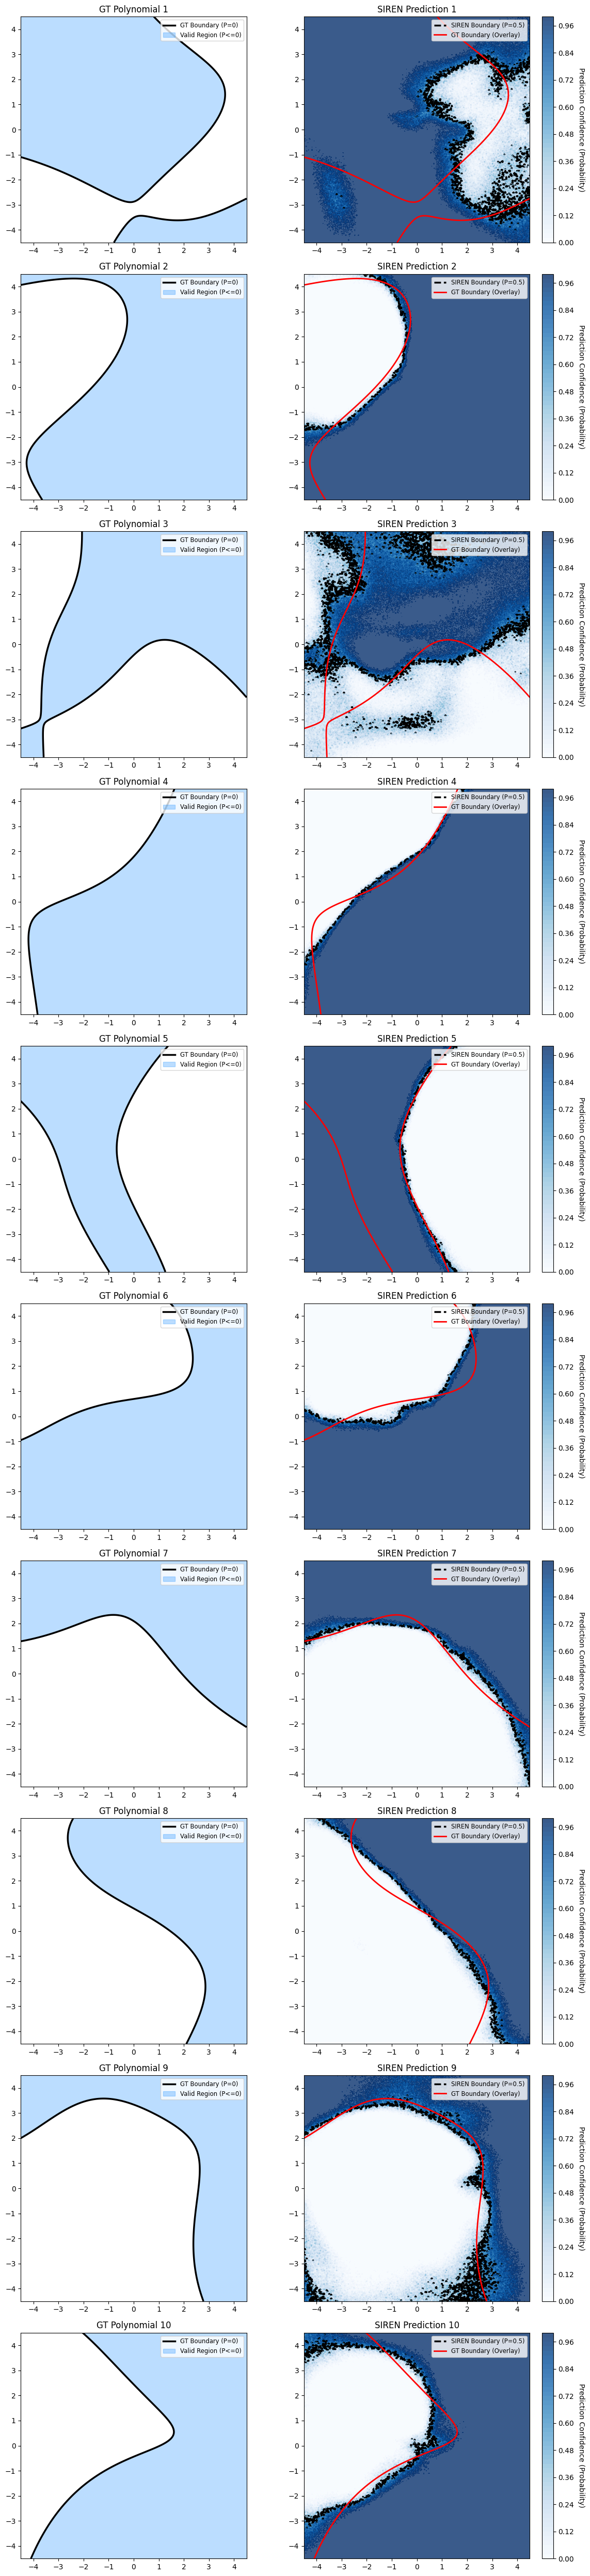

In [20]:
visualize_functa_extraction(siren, C, z_opt)

## Boundary Fidelity Metrics

MSE over uniformly-random points under-weights errors near the thin true boundary.
Pixel agreement / IoU between predicted and GT valid regions is a more direct,
interpretable measure of constraint-satisfaction fidelity.


In [ ]:
def evaluate_boundary_fidelity(siren, C, z_opt, scale=PLANE_SCALE, degree=POLYNOMIAL_DEGREE, resolution=200):
    """Computes per-shape pixel agreement and IoU between SIREN's predicted valid
    region (pred<=0) and the true polynomial's valid region (P<=0)."""
    device = next(siren.parameters()).device
    num_shapes = C.shape[0]

    x_lin = torch.linspace(-scale, scale, resolution)
    y_lin = torch.linspace(-scale, scale, resolution)
    grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')
    grid_pts_raw = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2).unsqueeze(0).repeat(num_shapes, 1, 1).to(device)

    x_pow, y_pow = compute_poly_features_batched(grid_pts_raw, degree=degree, scale=scale)
    P_vals = evaluate_poly_batched(x_pow, y_pow, C)
    gt_valid = P_vals <= 0

    grid_pts_scaled = grid_pts_raw / scale
    with torch.no_grad():
        preds = siren(grid_pts_scaled, z_opt).squeeze(-1)
    pred_valid = preds <= 0

    agreement = (gt_valid == pred_valid).float().mean(dim=1) * 100.0
    intersection = (gt_valid & pred_valid).float().sum(dim=1)
    union = (gt_valid | pred_valid).float().sum(dim=1)
    iou = (intersection / union.clamp(min=1)) * 100.0

    for i in range(num_shapes):
        print(f"Shape {i+1}: Pixel Agreement = {agreement[i]:.2f}% | IoU = {iou[i]:.2f}%")
    print(f"\nMean Pixel Agreement: {agreement.mean():.2f}% | Mean IoU: {iou.mean():.2f}%")

    return agreement, iou


In [ ]:
agreement, iou = evaluate_boundary_fidelity(siren, C, z_opt)


## Latent Space Interpolation Sanity Check

Verifies that linearly interpolating between two extracted Functa vectors produces
a smooth, coherent morphing between their constraint boundaries -- a prerequisite
for the thesis's claimed latent-arithmetic capability.


In [ ]:
def visualize_latent_interpolation(siren, C_pair, z_pair, num_steps=5,
                                    scale=PLANE_SCALE, degree=POLYNOMIAL_DEGREE, resolution=200):
    """Visualizes SIREN(x, z_t) for z_t linearly interpolated between two Functas."""
    device = next(siren.parameters()).device
    ts = torch.linspace(0, 1, num_steps, device=device)
    z_a, z_b = z_pair

    x_lin = torch.linspace(-scale, scale, resolution)
    y_lin = torch.linspace(-scale, scale, resolution)
    grid_y, grid_x = torch.meshgrid(y_lin, x_lin, indexing='ij')
    grid_pts = torch.stack([grid_x, grid_y], dim=-1).view(-1, 2).unsqueeze(0).to(device)
    grid_pts_scaled = grid_pts / scale

    fig, axes = plt.subplots(1, num_steps, figsize=(4 * num_steps, 4))

    with torch.no_grad():
        for i, t in enumerate(ts):
            z_t = (1 - t) * z_a + t * z_b
            preds = siren(grid_pts_scaled, z_t.unsqueeze(0)).squeeze(-1).view(resolution, resolution).cpu().numpy()

            ax = axes[i]
            ax.contourf(grid_x.numpy(), grid_y.numpy(), preds, levels=50, cmap='RdBu_r', vmin=-1, vmax=1)
            ax.contour(grid_x.numpy(), grid_y.numpy(), preds, levels=[0], colors='black', linewidths=2.0)
            ax.set_title(f"t = {t.item():.2f}")
            ax.set_aspect('equal')
            ax.set_xlim(-scale, scale)
            ax.set_ylim(-scale, scale)

    plt.tight_layout()
    plt.show()


In [ ]:
visualize_latent_interpolation(siren, (C[0], C[1]), (z_opt[0], z_opt[1]))


# Constrained FM (Functa-Conditioned)

### Build / Load Functa Conditioning Pool

Extracting Functa latents via CAVIA is the expensive part of this pipeline (dozens
of SIREN forward/backward passes per batch). Paying that cost once per iteration
for thousands of training iterations is prohibitively slow, so instead we extract
a large, reusable pool of (C, z) pairs *once* and sample from it for free during
training (see sample_from_functa_pool). The pool caches both orientations of each
polynomial (z_pos for C, z_neg for -C), so the "flip trick" invariant -- x_1
always satisfies its paired constraint -- still holds exactly at zero extra cost.


In [ ]:
proxy_x_pow = global_proxy_x_pow.squeeze(0)
proxy_y_pow = global_proxy_y_pow.squeeze(0)

pool_size = 20000
pool_chunk_size = 128

pool_path = Path(repo_path) / "constrained_fm" / "functa_dataset" / "functa_conditioning_pool.pt"

if pool_path.exists():
    print(f"Loading cached Functa pool from {pool_path}...")
    functa_pool = torch.load(pool_path, map_location=device)
else:
    print(f"Building a Functa pool of {pool_size} polynomials (one-time cost)...")
    functa_pool = build_functa_pool(
        siren, proxy_x_pow=proxy_x_pow, proxy_y_pow=proxy_y_pow,
        pool_size=pool_size, degree=poly_degree, scale=plane_scale,
        chunk_size=pool_chunk_size, device=device,
    )
    torch.save(functa_pool, pool_path)
    print(f"Saved Functa pool to {pool_path}")

functa_pool = {k: v.to(device) for k, v in functa_pool.items()}


### Training

In [ ]:
lr = 1e-3
batch_size = 1024

# Functa conditioning is a harder regression target than raw polynomial coefficients
# (the model only sees an approximate learned z + the SIREN's own approximate
# per-point prediction, not an exact analytic P(x)), so it needs a substantially
# longer schedule to converge. Each iteration is cheap now (pool-based, no SIREN
# calls), so a much larger budget is still fast.
iterations = 15001
print_every = 500

vf_functa = ConstrainedFlowMatcher(siren=siren, latent_dim=latent_dim).to(device)
path = AffineProbPath(scheduler=CondOTScheduler())
optim_functa = torch.optim.Adam(vf_functa.trainable_parameters(), lr=lr)
scheduler_functa = torch.optim.lr_scheduler.CosineAnnealingLR(optim_functa, T_max=iterations, eta_min=1e-5)

losses_functa = []

for i in tqdm(range(iterations)):
    optim_functa.zero_grad()

    x_1, _ = get_points(batch_size, device=device)
    x_0 = torch.randn_like(x_1).to(device)
    t = torch.rand(x_1.shape[0]).to(device)

    path_sample = path.sample(t=t, x_0=x_0, x_1=x_1)

    # Free (no SIREN calls): sampled from the precomputed pool built above.
    C, z = sample_from_functa_pool(path_sample.x_1, functa_pool, degree=poly_degree, scale=plane_scale)

    pred_v = vf_functa(path_sample.x_t, path_sample.t, z)

    loss = torch.pow(pred_v - path_sample.dx_t, 2).mean()
    loss.backward()
    optim_functa.step()
    scheduler_functa.step()

    losses_functa.append(loss.item())

    if (i + 1) % print_every == 0:
        current_lr = optim_functa.param_groups[0]['lr']
        print('| iter {:6d} | loss {:8.5f} | lr {:.2e}'.format(i + 1, loss.item(), current_lr))


In [ ]:
plot_loss_curve(losses_functa)


### Sampling

In [ ]:
x_1_test, _ = get_points(1, device=device)

C_test, z_test = generate_functa_conditioned_batch(
    siren, x_1_test,
    proxy_x_pow=proxy_x_pow, proxy_y_pow=proxy_y_pow,
    degree=poly_degree, scale=plane_scale,
    device=device,
)
C_test = C_test[0]
z_test = z_test[0]

generate_and_visualize_samples(
    model=vf_functa,
    x_true_pool=gmm_true_pool,
    coeffs=C_test,
    z=z_test,
    degree=poly_degree,
    scale=plane_scale,
)


#### In-Pool Sanity Check

Tests a constraint the model actually saw during training (sampled directly from
the pool, no fresh extraction) to disambiguate "undertrained overall" from
"generalizes poorly to novel out-of-pool shapes".


In [ ]:
pool_idx = torch.randint(0, functa_pool["C"].shape[0], (1,), device=device).item()
C_pool_test = functa_pool["C"][pool_idx]
z_pool_test = functa_pool["z_pos"][pool_idx]

generate_and_visualize_samples(
    model=vf_functa,
    x_true_pool=gmm_true_pool,
    coeffs=C_pool_test,
    z=z_pool_test,
    degree=poly_degree,
    scale=plane_scale,
)


### Compute Likelihood

In [ ]:
likelihood_functa = vf_functa.compute_likelihood_grid(
    z=z_test, siren=siren,
    degree=poly_degree, scale=plane_scale,
    device=device,
)

visualize_likelihood(likelihood_functa, coeffs=C_test, degree=poly_degree, scale=plane_scale, device=device)
